# Capstone Project

## Superconducting quantum circuits at the surface code threshold for fault tolerance

**Author : Murat Can Sarihan, Google Quantum AI**

**References**

1. Barends, R. et al. Coherent Josephson Qubit Suitable for Scalable Quantum Integrated Circuits. Phys Rev Lett 111, 080502 (2013).
2. Barends, R. et al. Superconducting quantum circuits at the surface code threshold for fault tolerance. Nature 508, 500–503 (2014).

In this task, we will design one of the important devices in the history of superconducting quantum computing. In Barends et al. (2014), John Martinis and his team, which will build the foundations of Google Quantum AI lab shortly after, demonstrated a full set of 1Q and 2Q gates with fidelities above the fault-tolerance threshold required for surface code error correction. The result made quantum error correction with surface codes is not only a proposal but a serious possibility, which is demonstrated later.

The team achieved an average single-qubit gate fidelity of 99.92% and a two-qubit gate fidelity of up to 99.4% by designing a 5-qubit linear array quantum processor, with tunable transmons (Xmon) and fixed coupling.

During this task, we will attempt to build the same device that enabled the later advancements. We will be using the circuit elements we designed during the workshop, and integrate to create the device given in Figure 1.

![Architecture. (a) Optical image of the integrated Josephson quantum processor, consisting of Al (dark) on sapphire (light). The five cross-shaped devices are the Xmon variant of the transmon qubit13 , labelled Q0 − Q4 , placed in a linear array. To the left of the qubits are five meandering coplanar waveguide resonators used for individual state readout. Control wiring is brought in from the contact pads at the edge of the chip, ending at the right of the qubits. (b) Circuit diagram. Our architecture employs direct, nearestneighbour coupling of the qubits (red/orange), made possible by the nodal connectivity of the Xmon qubit. Using a single readout line, each qubit can be measured using frequency-domain multiplexing (blue). Individual qubits are driven through capacitively-coupled microwave control lines (XY), and frequency control is achieved through inductively-coupled dc lines (Z) (purple). (c) Schematic representation of an entangling operation using a controlled-Z gate with unitary representation UCZ : (I) Qubits at rest, at distinct frequencies with minimal interaction. (II) When brought near resonance, the state-dependent frequency shift brings about a rotation conditional on the qubit states. (III) Qubits are returned to their rest frequency.](1.jpg)

**Figure 1: Architecture**. (a) Optical image of the integrated Josephson quantum processor, consisting of Al (dark) on sapphire (light). The five cross-shaped devices are the Xmon variant of the transmon qubit13 , labelled Q0 − Q4 , placed in a linear array. To the left of the qubits are five meandering coplanar waveguide resonators used for individual state readout. Control wiring is brought in from the contact pads at the edge of the chip, ending at the right of the qubits. (b) Circuit diagram. Our architecture employs direct, nearestneighbour coupling of the qubits (red/orange), made possible by the nodal connectivity of the Xmon qubit. Using a single readout line, each qubit can be measured using frequency-domain multiplexing (blue). Individual qubits are driven through capacitively-coupled microwave control lines (XY), and frequency control is achieved through inductively-coupled dc lines (Z) (purple). (c) Schematic representation of an entangling operation using a controlled-Z gate with unitary representation UCZ : (I) Qubits at rest, at distinct frequencies with minimal interaction. (II) When brought near resonance, the state-dependent frequency shift brings about a rotation conditional on the qubit states. (III) Qubits are returned to their rest frequency.

The processor has five qubits in a 1-D chain with maximum qubit frequency alternating between 5.8 GHz and 5 GHz approximately. The average nonlinearity, eta, of the qubits are around 215 MHz, while the coupling strength between two neighboring qubits are 30 MHz at 4.7 GHz. The qubits are apart from each other, enough to have 1.3 MHz next-nearest neighbour coupling strength.

| Qubit | Qubit Frequency (MHz)  | Coupling Strength Between Qubits (MHz) | Anharmonicity (MHz) | 
| :--- | :--- | :--- | :--- |  
| Q0 | 5805 |  $g_{01}$ : 27.7 | -217 | |
| Q1 | 5238 |  $g_{01}$ : 27.7, $g_{12}$ : 30.8 | -226 | 
| Q2 | 5780 |  $g_{12}$ : 30.8, $g_{23}$ : 30.4 | -214 | 
| Q3 | 5060 |  $g_{23}$ : 30.4, $g_{34}$ : 30.9 | -212 | 
| Q4 | 5696 |  $g_{34}$ : 30.9 | -223 | 

```

# Qubit Capacitance Simulation  using Palace

Let's start designing our qubit and simulating our qubit capacitances to obtain desired parameters using Palace. In this simulation, we replace the separate package layout with the qubit class `TransmonCrossFL` we used in the layout result. This allows us to verify the self-capacitance and mutual capacitance parameters of our physical design.

In [16]:
%load_ext autoreload
%autoreload 2
%config IPCompleter.greedy = True
%matplotlib inline
%config Completer.use_jedi = False
%config InlineBackend.figure_format = 'svg'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import os
os.environ['QISKIT_METAL_HEADLESS'] = 'True'

import qiskit_metal as metal
from qiskit_metal import designs, Dict
from qiskit_metal.qlibrary.qubits.transmon_cross_fl import TransmonCrossFL
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import schemdraw
import schemdraw.elements as elm
import schemdraw.flow as flow



hbar = 6.62607015e-034 / (2 * np.pi)  # J.s
flux_0 = hbar * np.pi / 1.6e-19   # J.s / phi_0

In [18]:
# Define path to the Palace executable
path_to_palace = "/Users/mcansarihan/qubit_design/palace/build/bin/palace"

# Transmon + Resonator System

Let's start discussing how a transmon qubit electrically look like. We can essentially identify a transmon qubit system with its control and readout system as a lumped electrical circuit. Below, we used a nice visualization package called "schemdraw" to draw an example transmon circuit.

In [19]:
# Install schemdraw if you haven't already: 
!pip install schemdraw

In [20]:
import schemdraw
import schemdraw.elements as elm
import schemdraw.flow as flow

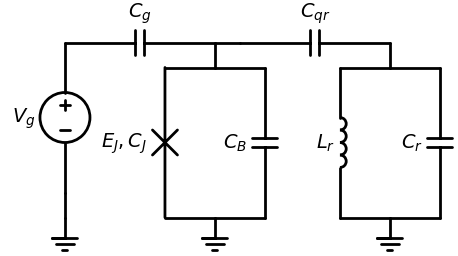

In [21]:
# Create a new drawing
d = schemdraw.Drawing()

# --- Define Nodes ---
bottom_node = (0,0) # Common ground node

# --- Draw the Transmon (Qubit) Circuit ---
# Drawing the charge line
d += elm.Ground().at(bottom_node)
d += elm.Line().up().length(0.5)
d += elm.SourceV().up().label('$V_g$')
d += elm.Capacitor().right().label('$C_g$')

# Drawing the qubit circuit
charge_node = d.here
d += elm.Line().down().length(0.5)
junction_node = d.here
d += elm.Line().left().length(1)
d += elm.Josephson().down().label('$E_J, C_J$')
d += elm.Line().right().length(1)
d += elm.Line().right().length(1).at(junction_node)
d += elm.Capacitor().down().label('$C_B$')
d += elm.Line().left().length(1)
d += elm.Ground()
d += elm.Line().right().length(0.5).at(charge_node)
d += elm.Capacitor().right().label('$C_{qr}$')

# Drawing the resonator circuit
d += elm.Line().down().length(0.5)
resonator_node = d.here
d += elm.Line().left().length(1)
d += elm.Inductor().down().label('$L_r$')
d += elm.Line().right().length(1)
d += elm.Line().right().length(1).at(resonator_node)
d += elm.Capacitor().down().label('$C_r$')
d += elm.Line().left().length(1)
d += elm.Ground()
d.draw()

A basic structure for a single qubit system can be drawn as above. We have the transmon at the center of the circuit, defined by the parallel branch of Josepshon junction and a shunting capacitor. We have added a capacitively-coupled control line to the left, which creates charge fluctuations on our qubit. In order to readout the quantum state of the qubit, we have coupled our qubit to a resonator, which is modeled as an LC resonator capacitively coupled from the right. We will use the dispersive readout concepts we learned throughout the workshop to design our readout circuit.

Our first task is determining the properties of our transmon. We will start with designing the Hamiltonian of the transmon.
The transmon Hamiltonian is given by: 

$$
\hat{H}=4E_{C}\left(\hat{n}-n_{g}\right)-E_{J}\cos\left(\hat{\phi}\right)\,,
$$

where $E_{C}$ is the charging energy, $E_{J}$ is the Josephson energy, $\hat n$ is the number of Cooper pairs transferred between charge islands, $\hat{\phi}$ is the phase difference between charge islands, and $n_{g}$ is effective offset charge of the device. Expressions for the charging energy, Josephson energy and offset charge can be written as:

$$
E_{C}=\frac{e^{2}}{2C_{\Sigma}}\,,\qquad n_{g}=-\frac{C_{d}\dot{\Phi}_{s}\left(t\right)}{2e}\:,\qquad E_{J}=\frac{\phi_{0}^{2}}{L_{J}}\,,
$$

where $C_{\Sigma} = C_{J}+C_{B}+C_{g}$ (the sum of the Josephson capacitance, shunting capacitance and gate capacitance), $L_{J}$ is the inductance of the Josephson junction, and $\phi$ is the magnetic flux. 

The  are
$$
\hat{\phi}\equiv\frac{\hat{\Phi}}{\phi_{0}},\qquad\hat{n}\equiv\frac{\hat{Q}}{2e}\,,
$$

Observe that $\hat \phi$ and $\hat n$ are both dimensionless, and they obey the commutation relationship:

$$
[\hat{\phi}, \hat{n}] = i
$$


Using the operator relations above, we can write the transmon Hamiltonian in the charge ($\hat n$) basis as given below, where $\hat{n} = \sum_{n=-\inf}^{\inf} |n\rangle\langle n|$: 

$$H=4E_\text{C}(\hat{n}-n_g)^2-\frac{1}{2}E_\text{J}\sum_n(|n\rangle\langle n+1|+\text{h.c.}),$$


Writing the transmon Hamiltonian this way will help us to easily diagonalize the Hamiltonian and extract our qubit resonances.

### Charge Dispersion

Let's model the hamiltonian to see how the energy structure looks like. For this purpose, we can either use the Hcpb (Hamiltonian - Cooper Pair Box) class within Qiskit Metal, or we can use the open source scqubits package.

Let's start by defining the range of offset charge from -2.0 to +2.0 and also by defining a normalization for the eigenvalues, which will be the transition energy between the first two states evaluated at the degeneracy point where ng=0.5. For this exercise, first we'll take Josephson Energy to be equal to the charging energy and then we will check how our system behaves for different Josephson energies.

NameError: name 'Hcpb' is not defined

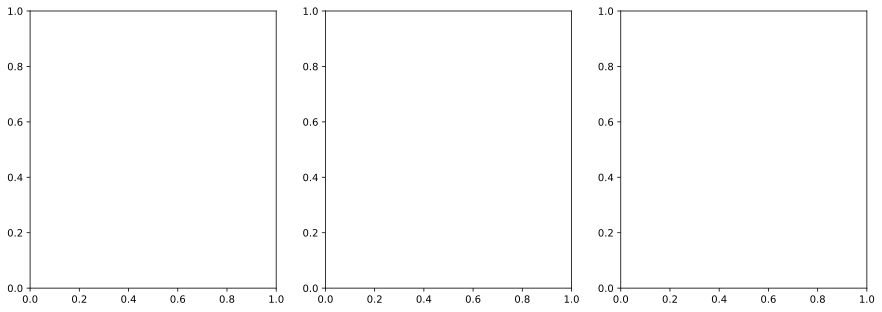

In [22]:

# Define the charging energies to iterate over
ng = np.linspace(-2.0,2.0,101) # this represents the charging energy (ng)
E_c = 220
E_j_values = [E_c * 1, E_c * 10, E_c*50]
# Create a figure with subplots
fig, axes = plt.subplots(1, len(E_j_values), figsize=(15, 5))

# Iterate over the charging energies
for ax_idx, E_j in enumerate(E_j_values):
    epsilon0, epsilon1, epsilon2, epsilon3 = [], [], [], []
    # Calculate charge dispersion for each Ej/Ec ratio
    for i in ng:
        H = Hcpb(nlevels=10, Ej=E_j, Ec=E_c, ng=i)
        H_norm = Hcpb(nlevels=2, Ej=E_j, Ec=E_c, ng=0.5)
        norm = H_norm.fij(0,1) # normalization constant
        epsilon0.append(H.evalue_k(0)/norm)
        epsilon1.append(H.evalue_k(1)/norm)
        epsilon2.append(H.evalue_k(2)/norm)
        epsilon3.append(H.evalue_k(3)/norm)
    floor = min(epsilon0)
    # Plot the charge dispersion on the current subplot
    ax = axes[ax_idx]
    ax.plot(ng, epsilon0-floor, 'k', label="m=0")
    ax.plot(ng, epsilon1-floor, 'b', label="m=1")
    ax.plot(ng, epsilon2-floor, 'r', label="m=2")
    ax.plot(ng, epsilon3-floor, 'g', label="m=3")
    ax.set_xlabel("$n_g$")
    ax.set_ylabel("Em/E01")
    ax.set_title(f"Ej/Ec = {E_j/E_c}")
    ax.legend(title="Energy Level", loc='upper right')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In the figures above, we see that the change in the frequency with the offset charges reduce with increasing $E_J/E_C$ ratio. This is very important for the coherence of our qubits, since the charge noise present in your environment would couple to your qubit anytime and cause frequency fluctuations. These frequency fluctuations cause incoherence for your qubits.


As we see here, for a transmon with equal inductive and capacitive energy, we observe huge swings in frequency with the gate charge, which is called charge dispersion.The peak-to-peak value of the charge dispersion for the mth energy level is given by the expression: $\epsilon_{m} = E_{m}(n_{g}=0.5) - E_{m}(n_{g}=0.0)$. We can plot $\epsilon_{m}/E_{01}$ as a function of $E_{J}/E_{C}$ for the first few energy levels.

We can start by defining a value of charging energy and creating empty lists for $\epsilon_{0}$ through $\epsilon_{4}$: 

In [ ]:
E_c=220.0 # charging energy 
epsilon0, epsilon1, epsilon2, epsilon3 = [], [], [], []    # charge dispersion for m=0 through m=4
x = np.linspace(1,140,101)           # this this ratio of Ej/Ec which will go on the x-axis. 

Next, we simply evaluate the expression given above for $\epsilon_{m}$ based on $E_{m}$ and $E_{0}$. We use two separate Hamiltonians to do this; one evaluated at $n_{g}=0.5$ and one evaluated at $n_{g}=0.0$. We also normalize by the transition energy between the lowest two states evaluated at the degeneracy point ($E_{01}$.) Finally, we populate the lists each $\epsilon_{m}$. 

In [ ]:
for i in x:
    E_j = i*E_c 
    H_zero = Hcpb(nlevels=15, Ej=i*E_c, Ec=E_c, ng=0.0)
    H_half = Hcpb(nlevels=15, Ej=i*E_c, Ec=E_c, ng=0.5)
    
    H_norm = Hcpb(nlevels=15, Ej=i*E_c, Ec=E_c, ng=0.5)
    norm = H_norm.fij(0,1)                         # normalization constant 
    
    epsilon0.append(abs(H_half.evalue_k(0) - H_zero.evalue_k(0))/norm)
    epsilon1.append(abs(H_half.evalue_k(1) - H_zero.evalue_k(1))/norm)
    epsilon2.append(abs(H_half.evalue_k(2) - H_zero.evalue_k(2))/norm)
    epsilon3.append(abs(H_half.evalue_k(3) - H_zero.evalue_k(3))/norm)

We can plot these values to see the exponential decrease in the charge dispersion with increasing $E_{J}/E_{C}$. The important feature of a transmon qubit is insensitivity to the charge noise due to large $E_J/E_C$ ratio. This is ensured by adding a parallel capacitance $C_B$ to the josephson junction.

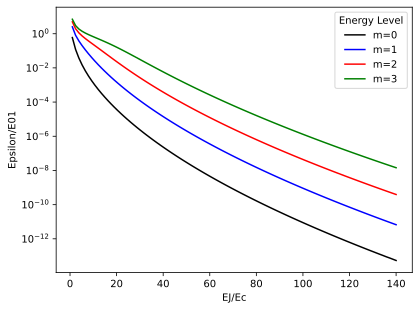

In [ ]:
plt.plot(x, epsilon0, 'k', label="m=0")
plt.plot(x, epsilon1, 'b', label="m=1")
plt.plot(x, epsilon2, 'r', label="m=2")
plt.plot(x, epsilon3, 'g', label="m=3") 
plt.yscale("log")
plt.xlabel("EJ/Ec")
plt.ylabel("Epsilon/E01")
plt.legend(title="Energy Level", loc='upper right')

Now, let's use another useful package called scqubits to calculate our transmon qubit frequencies. scqubits will help us to diagonalize our hamiltonian and extract the resonance of the qubit

In [ ]:
import scqubits as scq

qubit = scq.Transmon(
    EJ=22.6, # GHz, Josephson energy
    EC=0.2, # GHz, charging energy
    ng=0.001, # offset charge
    ncut=40, # number of levels to consider
    truncated_dim=4     # after diagonalization, we will keep 3 levels
)
evals = qubit.eigenvals(evals_count=12)
frequency_q = (evals[1] - evals[0])
print(f"Frequency of 01 transition = {(evals[1] - evals[0])* 1000:.0f} MHz")
print(f"Anharmonicity = {((evals[2] - evals[1]) - (evals[1] - evals[0]))* 1000:.0f} MHz")

Frequency of 01 transition = 5806 MHz
Anharmonicity = -218 MHz


We set our qubit to have an $E_J/E_C$ ratio of 100. Let's have a look at how our qubit wavefunction looks like in terms of charge and flux basis.

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

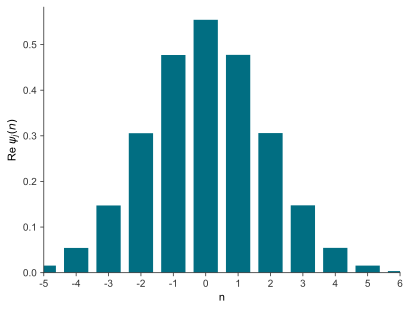

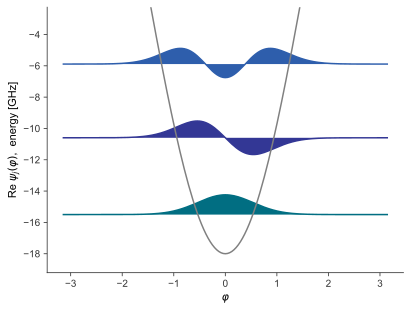

In [ ]:
#Plot the wavefunction in charge and flux basis
qubit.plot_n_wavefunction()
qubit.plot_phi_wavefunction(which=[0,1,2], mode='real')

As we see, our qubit wavefunction is highly delocalized in the charge basis, while it is localized in flux basis within the cosine potential due to Josephson junction. This delocalization helps us to be independent from the offset gate charge fluctuations.

Spectral data:   0%|          | 0/220 [00:00<?, ?it/s]

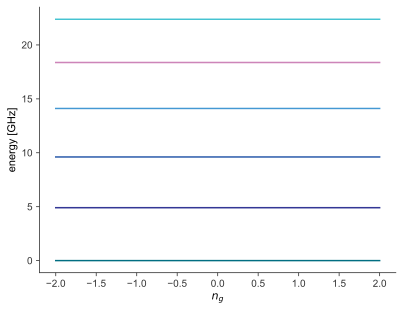

In [ ]:
#Again, we can plot the eigenvalues as a function of gate charges to get an idea of charge dispersion.
ng_list = np.linspace(-2, 2, 220)
qubit.plot_evals_vs_paramvals('ng', ng_list, evals_count=6, subtract_ground=True);

As we see from the wavefunction in the flux basis, we can identify our transmon as a weakly anharmonic oscillator in flux basis and diagonalize the Hamiltonian to obtain our energy eigenstates in terms of ladder operations $\hat{b}$ and $\hat{b}^{\dag}$, i.e. number of excitations. 

In this case, our Hamiltonian becomes:

$$
\hat{H}= \hbar\omega_q \hat{b}^{\dag}\hat{b}-\frac{E_C}{2} \hat{b}^{\dag}\hat{b}^{\dag}\hat{b}\hat{b}
$$
where, $\hbar\omega_q = \sqrt{8E_CE_J}-E_C$, which corresponds to the transition frequency between ground and first excited state. This transition is where quantum states are logically assigned.

The second component of the Hamiltonian depends on number of excitations present, which changes the transition frequency between higher excited states. This term is what makes our transmon oscillator anharmonic, where transition frequencies between each level are different from each other. The anharmonicity(or qubit nonlinearity) $\alpha$ is approximately equal to $E_C$, and helps us to distinguish between different qubit transitions, which is important for high-fidelity control of the qubits and prevent leakage to higher order transitions.

While designing a qubit, the important considerations are:
- Determine $E_J$ and $E_C$ according to the desired qubit frequency
- Having a large enough $E_J/E_C$ ratio to suppress the effects of charge noise
- Finally, having an appropriate $E_C$ (~100-400 MHz) to achieve better control and prevent leakage.

In summary, the $E_J$ and $E_C$ values are not independent from each other and should be carefully determined according to the qubit frequency regime desired for operation. Let's use the transmon parameters we used to simulate with scqubits to design our device.

In [25]:
import qiskit_metal.analyses.quantization.lumped_capacitive as lumped_cap
E_c = 0.2 # charging energy # GHz
E_j = 22.6 # Josephson energy
C_shunt  = lumped_cap.Cs_from_Ec(hbar*2*np.pi*E_c*1e9)  # input in Joules, thus multiplied by Planck's constant
I_junction = lumped_cap.Ic_from_Ej(hbar*2*np.pi*E_j*1e9) #input in Joules, thus multiplied by Planck's constant
L_junction = flux_0 / (2 * np.pi * I_junction) # in H
print(f"Shunt capacitance = {C_shunt*1e15:.2f} fF")
print(f"Junction critical current = {I_junction*1e9:.2f} nA")
print(f"Junction inductance = {L_junction*1e9:.2f} nH")
# Calculate the ratio of EJ/EC
print(f"EJ/EC = {E_j/E_c:.2f}")

Shunt capacitance = 96.85 fF
Junction critical current = 45.52 nA
Junction inductance = 7.24 nH
EJ/EC = 113.00


## Tunable Transmon

State of the art transmon devices are designed to have a tunable frequency, in order to be able to tune qubit properties to have best coherence, or to bring two qubits in resonance for achieving high-fidelity two qubit gate operations. For this purpose, the single Josephson Junction in transmon is replaced by a SQUID loop of two parallel Josephson Junctions. Such a qubit can be tuned by applying an external magnetic field within the loop. 

The flux sensitivity of tunable transmons can be reduced at the expense of tunable range, which improves coherence of the qubit under the presence of flux noise.

The Hamiltonian of a tunable transmon becomes :

$$
H = 4E_C\hat{n}^2 - E_{J\Sigma}\sqrt{cos^2(\phi_{ext})+ d^2 sin^2(\phi_{ext})} cos(\phi)
$$
where $E_{J\Sigma} = E_{J1} + E_{J2}$ and $ d = E_{J1} - E_{J2}/E_{J\Sigma}$. Thus we can treat this Hamiltonian as a single-junction transmon with effective Josepshon energy of $E_{J\Sigma}\sqrt{cos^2(\phi_{ext})+ d^2 sin^2(\phi_{ext})}$. The Josephson energy is controlled by the external flux $\phi_{ext}$.

Spectral data:   0%|          | 0/220 [00:00<?, ?it/s]

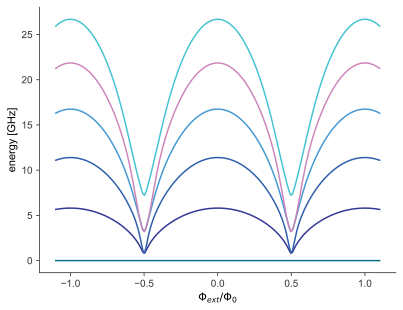

In [26]:
tune_tmon = scq.TunableTransmon(
    EJmax=22.6,
    EC=0.2,
    d=0,
    flux=0.0,
    ng=0.0,
    ncut=40
)

flux_list = np.linspace(-1.1, 1.1, 220)
tune_tmon.plot_evals_vs_paramvals('flux', flux_list, subtract_ground=True);

## Initialize Design and Qubit Geometry

In [5]:
design = designs.DesignPlanar()
design.chips.main.size.size_x = '2.4mm'
design.chips.main.size.size_y = '2.4mm'
design.chips.main.size.size_z = '-280um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '0mm'

In [6]:
# Instantiate the qubit matching our 5-qubit processor layout parameters
q = TransmonCrossFL(design, 'Q0', options=dict(
    pos_x='0.0mm',
    pos_y='0.0mm',
    orientation='0',
    cross_width='30um',
    cross_length='200um',
    cross_gap='40um',
    make_fl=True,
    fl_options=dict(
        t_gap='3um', 
        t_inductive_gap='3um', 
        t_offset='0um', 
        t_top='15um', 
        t_width='5um',
    ),
    connection_pads=dict(
        readout=dict(
            connector_type='0', 
            claw_length='40um', 
            ground_spacing='0um', 
            claw_width='10um', 
            claw_gap='6um', 
            connector_location='90' # North arm
        ),
    )
))

design.rebuild()

## Configure Palace Capacitance Simulation

In [7]:
from SQDMetal.PALACE.Capacitance_Simulation import PALACE_Capacitance_Simulation

# Define the options for the simulation
user_defined_options = {
                "mesh_refinement": 2,                             #refines mesh in PALACE
                "dielectric_material": "silicon",                  #choose dielectric material
                "solver_order": 1,                                 #increasing solver order increases accuracy of simulation
                "solver_tol": 1.0e-8,                              #error residual tolerance
                "solver_maxits": 500,                              #number of solver iterations
                "mesh_max": 120e-6,                                #maximum element size for the mesh in m
                "mesh_sampling": 150,                              #number of points to mesh along a geometry
                "fillet_resolution": 12,                            #number of vertices per quarter turn on a filleted path
                "num_cpus": 5,                                    #number of CPU cores to use for simulation
                "palace_dir": path_to_palace
                }

In [8]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["PMIX_MCA_gds"]="hash"

import gmsh
gmsh.initialize()

os.makedirs('sims', exist_ok=True)

In [9]:
cap_sim = PALACE_Capacitance_Simulation(name = 'transmon_cross_cap_sim',                                 #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "sims/",            #choose directory where mesh/json files are saved
                                        mode = 'simPC',                                             #choose simulation mode
                                        meshing = 'GMSH',                                           #choose meshing
                                        user_options = user_defined_options,                        #provide options chosen above
                                        view_design_gmsh_gui = False,                               #view design in GMSH gui
                                        create_files = True,
                                        )
# adding metallic and ground planes
cap_sim.add_metallic(1, threshold=1e-10, fuse_threshold=1e-10)
cap_sim.add_ground_plane(threshold=1e-10)

In [10]:
# Retrieve the bounds of the qubit area for finer meshing
bounds = design.components["Q0"].qgeometry_bounds()
# Fine-mesh the transmon cross qubit region
cap_sim.fine_mesh_in_rectangle(bounds[0]*1e-3, bounds[1]*1e-3, bounds[2]*1e-3, bounds[3]*1e-3, mesh_sampling=100, mesh_min=.5e-6, mesh_max=30e-3)

In [11]:
# prepare the simulation files
cap_sim.prepare_simulation()

  fig.show()



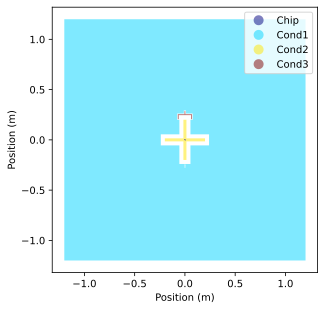

In [12]:
# Display conductor indices to check column indexing
fig = cap_sim.display_conductor_indices()
fig.show()
# fig.savefig('sims/terminal_indices.png')
# plt.close(fig)

In [13]:
# Run Palace capacitance simulation solver
cap_matrix = cap_sim.run()

>> /opt/homebrew/bin/mpirun -n 5 /Users/mcansarihan/qubit_design/palace/build/bin/palace-arm64.bin transmon_cross_cap_sim.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)
Git changeset ID: v0.13.0-454-gcd4d7b78
Running with 5 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 95 elements in 2 iterations of local bisection for under-resolved interior boundaries
Added 3952 duplicate vertices for interior boundaries in the mesh
Added 8450 duplicate boundary elements for interior boundaries in the mesh
Added 522 boundary elements for material interfaces to the mesh
Finished partitioning mesh into 5 subdomains

Characteristic length and time scales:
 L₀ = 2.880e-03 m, t₀ = 9.607e-03

--------------------------------------------------------------------------
prterun has exited due to process rank 2 with PID 8903 on node Murats-MacBook-Air exiting
improperly. There are three reasons this could occur:

1. this process did not call "init" before exiting, but others in the
job did. This can cause a job to hang indefinitely while it waits for
all processes to call "init". By rule, if one process calls "init",
then ALL processes must call "init" prior to termination.

2. this process called "init", but exited without calling "finalize".
By rule, all processes that call "init" MUST call "finalize" prior to
exiting or it will be considered an "abnormal termination"

3. this process called "MPI_Abort" or "prte_abort" and the mca
parameter prte_create_session_dirs is set to false. In this case, the
run-time cannot detect that the abort call was an abnormal
termination. Hence, the only error message you will receive is this
one.

This may have caused other processes in the app

Error in plotting: 'Data array (V) not present in this dataset.'


In [15]:
cdf = pd.DataFrame(cap_matrix * 1e15)

# get rid of the first column
cdf = cdf.iloc[:, 1:]

# assigning the columns and indices based on our geometry
cdf.columns = ["ground", "xmon", "claw"]
cdf.index = ["ground", "xmon", "claw"]
cdf = cdf.reindex(index=["ground", "claw", "xmon"], columns=["ground", "claw", "xmon"])
cdf

,ground,claw,xmon
ground,2458.404261,-35.744195,-78.374488
claw,-35.744195,40.312232,-2.097019
xmon,-78.374488,-2.097019,100.562415


# Coupling two transmons

In [ ]:
%load_ext autoreload
%autoreload 2
%config IPCompleter.greedy = True
%matplotlib inline
%config Completer.use_jedi = False
%config InlineBackend.figure_format = 'svg'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
os.environ['QISKIT_METAL_HEADLESS'] = 'True'
from qiskit_metal.analyses.hamiltonian.transmon_charge_basis import Hcpb
from qiskit_metal.analyses.hamiltonian.transmon_CPB_analytic import Hcpb_analytic
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


import scqubits as scq
from scqubits import HilbertSpace, InteractionTerm, ParameterSweep

import qiskit_metal as metal
from qiskit_metal import designs, draw
import pyEPR as epr
from qiskit_metal.qlibrary.couplers.tunable_coupler_01 import TunableCoupler01

from qiskit_metal.qlibrary.qubits.transmon_cross_fl import TransmonCrossFL
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
import qiskit_metal.analyses.quantization.lumped_capacitive as lumped_cap
import qiskit_metal.analyses.quantization.lumped_oscillator_model as lom_func
from collections import OrderedDict
# from squadds.components.qubits import TransmonCross
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
# from squadds.components.airbridge.airbridge_generator import AirbridgeGenerator
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
import schemdraw

import schemdraw
import schemdraw.elements as elm
import schemdraw.flow as flow
import numpy as np
import matplotlib.pyplot as plt
from SQDMetal.Comps.Xmon import Xmon
from SQDMetal.Comps.Junctions import JunctionDolanPinStretch
from SQDMetal.Comps.Capacitors import CapacitorProngPin
from SQDMetal.Utilities.Materials import MaterialInterface

path_to_palace = "/Users/mcansarihan/qubit_design/palace/build/bin/palace"
hbar = 6.62607015e-034 / (2 * np.pi)  # J.s
flux_0 = hbar * np.pi / 1.6e-19   # J.s / phi_0

Here, we will discuss one of most basic form of coupling between two qubits. In this case, we have two xmons with a capacitive coupling mediated by a bus. A similar form of coupling can be established by bringing two qubit pads close to each other.

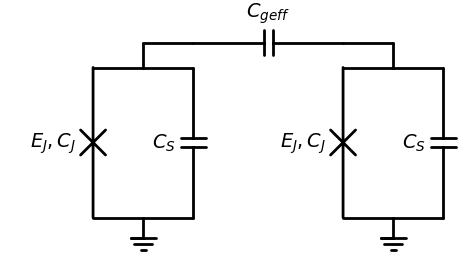

In [ ]:
# Create a new drawing
d = schemdraw.Drawing()

# --- Define Nodes ---
bottom_node = (0,0) # Common ground node


# Drawing the qubit circuit
charge_node = d.here
d += elm.Line().down().length(0.5)
junction_node = d.here
d += elm.Line().left().length(1)
d += elm.Josephson().down().label('$E_J, C_J$')
d += elm.Line().right().length(1)
d += elm.Line().right().length(1).at(junction_node)
d += elm.Capacitor().down().label('$C_S$')
d += elm.Line().left().length(1)
d += elm.Ground()
d += elm.Line().right().length(1).at(charge_node)
d += elm.Capacitor().right().label('$C_{geff}$')
d += elm.Line().right().length(1)
# Drawing the resonator circuit
d += elm.Line().down().length(0.5)
resonator_node = d.here
d += elm.Line().left().length(1)
d += elm.Josephson().down().label('$E_J, C_J$')
d += elm.Line().right().length(1)
d += elm.Line().right().length(1).at(resonator_node)
d += elm.Capacitor().down().label('$C_S$')
d += elm.Line().left().length(1)
d += elm.Ground()
d.draw()

The total Hamiltonian of this system can be simplified as:
$$
H = H_1 + H_2 + H_{int}
$$,
which is sum of both qubit energies and the interaction energy between two sides of the circuit, $H_{int}$. The interaction energy is in the form of $H_{int} = C_g V_1 V_2$, where $C_g$ is coupling capacitance and $V_i$ is voltage operator. 

Using circuit quantization methods, we can get this interaction Hamiltonian as:
$$
H_{int} = 4e^2 \frac{C_g}{C_1 C_2}\hat{n}_1\hat{n}_2
$$

In this section, we will first find the effective coupling capacitance $C_g$ and calculate the coupling strength between two qubits.

In [ ]:
design = designs.DesignPlanar({}, overwrite_enabled=True)
design.delete_all_components()

qubit_pitch = 0.45 #mm
# Set up chip dimensions 
design.chips.main.size.size_x = '2mm'
design.chips.main.size.size_y = '2mm'
design.chips.main.size.size_z = '-280um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '0mm'

# Resonator and feedline gap width (W) and center conductor width (S) 
design.variables['cpw_width'] = '10 um' #S
design.variables['cpw_gap'] = '40 um' #W 
# Lets create the qubit with a junction and a claw

## Qubit
q1 = TransmonCrossFL(design, 'Q1', options=dict(
    pos_x=f'-{qubit_pitch/2}mm', pos_y='0.0mm', orientation='0',
    cross_width='30um', cross_length='190um', cross_gap='50um',
    make_fl=True,
    fl_options=dict(t_gap='3um', t_inductive_gap='3um', t_offset='0um', t_top='15um', t_width='5um')
))



q2 = TransmonCrossFL(design, 'Q2', options=dict(
    pos_x=f'{qubit_pitch/2}mm', pos_y='0.0mm', orientation='0',
    cross_width='30um', cross_length='190um', cross_gap='50um',
    make_fl=True,
    fl_options=dict(t_gap='3um', t_inductive_gap='3um', t_offset='0um', t_top='15um', t_width='5um')
))



design.rebuild()



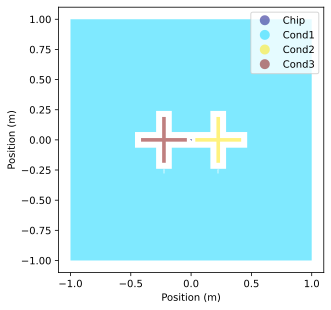

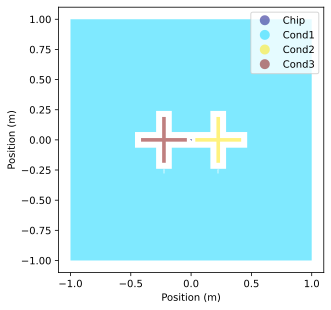

In [ ]:
from SQDMetal.PALACE.Capacitance_Simulation import PALACE_Capacitance_Simulation

user_defined_options = {
                "mesh_refinement": 1,                             #refines mesh in PALACE - essetially divides every mesh element in half
                "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                "solver_order": 1,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                "solver_tol": 1.0e-8,                              #error residual tolerance for iterative solver
                "solver_maxits": 500,                              #number of solver iterations
                "mesh_max": 120e-6,                                #maxiumum element size for the mesh in mm
                "mesh_sampling": 150,                              #number of points to mesh along a geometry
                "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                "num_cpus": 10,                                      #number of CPU cores to use for simulation
                "palace_dir":path_to_palace
                }
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["PMIX_MCA_gds"]="hash"

import gmsh
gmsh.initialize()


os.makedirs('sims', exist_ok=True)
#Creat the Palace Eigenmode simulation
cap_sim = PALACE_Capacitance_Simulation(name = 'transmon_cross_cap_sim',                                 #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "sims/",            #choose directory where mesh file, config file and HPC batch file will be saved
                                        mode = 'simPC',                                             #choose simulation mode 'HPC' or 'simPC'
                                        meshing = 'GMSH',                                           #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        view_design_gmsh_gui = False,                               #view design in GMSH gui
                                        create_files = True,
                                        )                                        #create mesh, config and HPC batch files

cap_sim.add_metallic(1, threshold=1e-10, fuse_threshold=1e-10)
cap_sim.add_ground_plane(threshold=1e-10)

for ii in ["Q1", "Q2"]:
    bounds = design.components[ii].qgeometry_bounds()
#Fine-mesh the transmon cross qubit region
    cap_sim.fine_mesh_in_rectangle(bounds[0]*1e-3, bounds[1]*1e-3, bounds[2]*1e-3, bounds[3]*1e-3, mesh_sampling=100, mesh_min=1e-6, mesh_max=50e-3)

cap_sim.prepare_simulation()
cap_sim.display_conductor_indices()





In [ ]:
# from SQDMetal.PALACE.Utilities.GMSH_Navigator import GMSH_Navigator

# # Let's look how the mesh looks in GMSH
# # Open the GMSH GUI

# gmsh_nav = GMSH_Navigator(cap_sim.path_mesh)
# gmsh_nav.open_GUI()

In [ ]:
cap_matrix = cap_sim.run()

>> /opt/homebrew/bin/mpirun -n 10 /Users/mcansarihan/qubit_design/palace/build/bin/palace-arm64.bin transmon_cross_cap_sim.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)
Git changeset ID: v0.13.0-454-gcd4d7b78
Running with 10 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 156 elements in 2 iterations of local bisection for under-resolved interior boundaries
Added 5452 duplicate vertices for interior boundaries in the mesh
Added 11702 duplicate boundary elements for interior boundaries in the mesh
Added 440 boundary elements for material interfaces to the mesh
Finished partitioning mesh into 10 subdomains

Characteristic length and time scales:
 L₀ = 2.400e-03 m, t₀ = 8.00

In [ ]:
cdf = pd.DataFrame(cap_matrix*1e15)

# get rid of the first column
cdf = cdf.iloc[:, 1:]

# assigning the columns and indices based on our geometry
cdf.columns = ["ground", "xmon2","xmon1"]
cdf.index = ["ground", "xmon2", "xmon1"]
cdf

,ground,xmon2,xmon1
ground,1764.588364,-69.497798,-69.542141
xmon2,-69.497798,92.539700,-1.224903
xmon1,-69.542141,-1.224903,92.593899


Based on the capacitance between two qubits, we can estimate our unitless coupling efficiency: $k_{q1q2} = C_g/\sqrt{C_1C_2}$

In [ ]:
coupling_eff = np.abs(cdf.loc["xmon2", "xmon1"]/np.sqrt(cdf.loc["xmon1","xmon1"]*cdf.loc["xmon2","xmon2"]))
print(f"Coupling Efficiency = {coupling_eff*100:.2f}%")

Coupling Efficiency = 1.32%


We will use our approximation to estimate the coupling strength between the two qubits.

$$
g = k_{q1q2} \sqrt{f_{q1} f_{q2}}/2
$$

In [ ]:
frequency_q1 = 4.7e9
frequency_q2 = 4.7e9

g = coupling_eff * frequency_q1 / 2 
print(f"Coupling Strength = {g*1e-6:.2f} MHz")

Coupling Strength = 31.10 MHz


Using the second quantization, we can represent the interaction Hamiltonian as:

$H_{int} = g (a_1-a_1^†) (a_2-a_2^†)$
where $a_1$ and $a_2$ are the annihilation operators for the two qubits. 
If we truncate the higher energy levels and restrict our qubits to Pauli basis (only 0-1 levels), we can reduce this Hamiltonian to:
$$
H = \frac{1}{2} \omega_{q1}\sigma_{z1} + \frac{1}{2}  \omega_{q2}\sigma_{z2} + g\sigma_{y1}\sigma_{y2}
$$
We see that the resulting coupling term is on y-axis, which is arbitrary and can also be identified by x axis. This indicates the presence of an exchange interaction between the qubits and called as transverse coupling. Transverse coupling can be used to perform two-qubit entangling gates such as SWAP family of gates.

Of course, this holds only when the system is truncated to the first two energy levels and ignores the presence of higher order states and couplings. In reality, two qubits have a mix of both transverse and longitudinal couplings(in z-basis) during the operation.

Another caveat is, these kind of static capacitive interactions are always on, which poses a problem to coherence of the qubits when they are idle. In order to overcome these challenges, state-of-the-art implementations utilize tunable coupling schemes, where a second coupling channel with tunable coupling strength is used to negate the static capacitive coupling between two qubits.